# 003 - London Breakout Strategy
 

  
  
♾️ Summary, commentary on key topics, analysis of main concepts and takeaways  
‼️ Limitations, threats, and warnings concerning data accuracy, backtest reliability, or other biases/fallacies    
🔆 Leading suggestions and refinements, ways to improve code or robustness of the strategy 

[MoneyforNotn](https://github.com/MoneyforNotn)

Python version: [3.13.7](https://www.python.org/downloads/)

# London Breakout on FX (Rules & Logic)

The London Breakout Strategy is a well-known intraday trading approach that aims to profit from the increased liquidity and volatility of the Forex market during the London session. When London opens, it overlaps with the end of the Asian session and leads into the U.S. session, often triggering large price moves. The method identifies the trading range established in the calmer Asian hours and takes positions when price breaks out above or below that range.

<div class="alert alert-block alert-info">
<b>♾️</b> 
Strategy aims to capitalize on the London trading session’s high liquidity and volatility following price 'breakouts' (from the Asian session's high/low) which can dictate the price movement direction for the remainder of the day
</div>

#### *Rules*  
Mark the high/low formed during the Asian session and watch for breakouts as London session begins  
A breakout above the range suggests a long opportunity while a breakout below suggests a short   
`Stop Loss` set at the lowest price over the past 60, not less than 25 pips from entry price  
`Take Profit` set at 1.4 times the SL, not more than 75 pips from entry price  
No other position is currently open or have occured on that day

#### *"Breakout"*
Strategyidentifies trading opportunities at the opening of the London session by looking for price breakouts from the previous Asian session's high or low (price crosses over/below the high/low of a lookback period or defined session)

## Data Universe

Since this strategy relies on liquidity and volatility, the FX pairs that provide the best result would be the ones which are most commonly traded... GBPUSD, EURUSD, and EURGBP are preferable

**1.1 & 1.2** -- EURUSD (5 MIN, OHLCV, Range: 07/22/2024-07/18/2025 (12 months))  

**1.3** -- EURUSD (5 MIN, OHLCV, Range: 07/21/2015-02/14/2026 (7 months))  

## **Backtesting Systems & Methods**

***Backtesting.py***  
[Backtesting.py](https://kernc.github.io/backtesting.py/) - open-source Python library for backtesting, optimizing, plotting & comparing performance metrics

***1.1 - Strategy Evaluation***

Datetime data prep, strategy definition, visualize price breakouts and tp/sl, plot and interpret results

***1.2 - Strategy Improvements (Time & Trend Filters)***

Improve robustness and performance by applying duration and trend filters identified in evaluation

***1.3 - Out of Sample Backtest***

New testing universe, mitigating Selection Bias, visualize equity curves, evaluation


### *CREDITS*

Historical price data from [dukascopy.com](https://www.dukascopy.com/swiss/english/marketwatch/historical/)  
**Yves Hilpisch**, *O'REILLY*, 2021, Python for Algorithmic Trading   
[wire.insiderfinance.io](https://wire.insiderfinance.io/backtest-results-revealed-is-the-london-breakout-strategy-worth-it-0e9df65dd63b) Backtest Results Revealed: Is the London Breakout Strategy Worth It?

***  
 ## ***1.1 - Strategy Evaluation***
***

## Libraries

In [18]:
import pandas as pd
import numpy as np
from enum import Enum
import pytz
from datetime import datetime, time
import mplfinance as mpf
import matplotlib.pyplot as plt
from backtesting import Backtest, Strategy
from backtesting import set_bokeh_output
set_bokeh_output(notebook=False)


### Data file preparation

Rename columns to match the Backtesting.py OHLC convention  
Convert the 'time' column to datetime objects  
Localize the 'time' column to UTC, set 'time' column as the DataFrame index, drop unwanted columns

In [19]:
new_df = pd.read_csv('003/data_EURUSD_cl.csv', delimiter=',')

new_df.rename(columns={
    'open': 'Open',
    'high': 'High',
    'low': 'Low',
    'close': 'Close'
}, inplace=True)

# The format is 'YYYY-MM-DD HH:MM:SS'
new_df['time'] = pd.to_datetime(new_df['time'], format='%Y-%m-%d %H:%M:%S')

# Explicitly localize it to make it timezone-aware UTC
new_df['time'] = new_df['time'].dt.tz_localize('UTC')
new_df.set_index('time', inplace=True)
new_df.drop(columns=['tick_volume', 'spread', 'real_volume'], inplace=True)

# Display the head and tail of the processed DataFrame
print("Processed DataFrame Head (first 5 rows):")
print(new_df.head())

print("\nProcessed DataFrame Tail (last 5 rows):")
print(new_df.tail())

Processed DataFrame Head (first 5 rows):
                              Open     High      Low    Close
time                                                         
2024-07-22 00:00:00+00:00  1.08829  1.08849  1.08829  1.08840
2024-07-22 00:15:00+00:00  1.08840  1.08857  1.08840  1.08853
2024-07-22 00:30:00+00:00  1.08853  1.08853  1.08827  1.08829
2024-07-22 00:45:00+00:00  1.08829  1.08850  1.08817  1.08842
2024-07-22 01:00:00+00:00  1.08843  1.08887  1.08843  1.08877

Processed DataFrame Tail (last 5 rows):
                              Open     High      Low    Close
time                                                         
2025-07-18 22:45:00+00:00  1.16185  1.16227  1.16178  1.16219
2025-07-18 23:00:00+00:00  1.16216  1.16263  1.16212  1.16257
2025-07-18 23:15:00+00:00  1.16257  1.16270  1.16243  1.16260
2025-07-18 23:30:00+00:00  1.16261  1.16270  1.16254  1.16261
2025-07-18 23:45:00+00:00  1.16261  1.16284  1.16190  1.16249


Now we'll extend the OHLC dataframe with the fields required for backtesting. First, add boolean columns indicating when each market is open. For instance, “LondonOpen” is True while the London market is open. Note that, for this strategy, “AsiaOpen” should be True when Sydney and Tokyo are open but False during the Tokyo–London overlap, since highs and lows must be calculated at London open and not earlier

`def is_market_open` checks if a specific Forex market (London, Tokyo, New York) is open at a given GMT/UTC time, accounting for **Daylight Saving Time (DST)**

Args:
        market (ForexMarket): The specific Forex market to check.
        gmt_time (datetime): The current time, which MUST be timezone-aware (UTC).

Returns:
        bool: True if the market is open, False otherwise.

**DST Calculation for Northern Hemisphere**

This logic approximates DST transitions based on typical Northern Hemisphere rules (last Sunday of March, last Sunday of October).It finds the last Sunday of March (for DST start) and October (for DST end) in the given year.

<div class="alert alert-block alert-danger">
<b>‼️</b> 
DTS logic uses approximations and might not perfectly match all historical DST changes or specific market-defined DST rules (which can sometimes vary slightly)
</div>

`market_hours` assumes Summer time market session hours, else uses Winter time hours

In [20]:
class ForexMarket(Enum):
    LONDON = "London"
    TOKYO = "Tokyo"
    SYDNEY = "Sydney"
    NEW_YORK = "New York"

# Function takes a ForexMarket enum member and a timezone-aware datetime object (gmt_time) as input.

def is_market_open(market: ForexMarket, gmt_time: datetime) -> bool:
    # The new_df index should already be UTC-aware, but this check adds robustness.
    if gmt_time.tzinfo is None:  # If it's a naive datetime (without timezone info)
        # Assume it's UTC if no tzinfo, then localize it, prevents potential errors
        gmt_time = pytz.UTC.localize(gmt_time)
    elif gmt_time.tzinfo != pytz.UTC:
        # If it's 'aware' but not UTC, convert it to UTC for consistent comparison
        gmt_time = gmt_time.astimezone(pytz.UTC)

# DST Calculation for Northern Hemisphere
    dst_start = datetime(gmt_time.year, 3, 31, 1, tzinfo=pytz.UTC) # Start of Mar 31
    while dst_start.weekday() != 6: # Go back until Sunday (weekday() for Sunday is 6)
        dst_start -= pd.Timedelta(days=1)
    dst_start = dst_start.replace(hour=1) # Market typically opens at 1am UTC for DST change

    dst_end = datetime(gmt_time.year, 10, 31, 1, tzinfo=pytz.UTC) # Start of Oct 31
    while dst_end.weekday() != 6: # Go back until Sunday
        dst_end -= pd.Timedelta(days=1)
    dst_end = dst_end.replace(hour=1) # Market typically opens at 1am UTC for DST change


    # Define market open and close times in GMT/UTC
    if dst_start <= gmt_time < dst_end:
        # SUMMER TIME (when countries like UK are in BST, which is UTC+1; or New York is EDT, UTC-4)
        market_hours = {
            ForexMarket.LONDON: (time(7, 0), time(16, 0)),  # 8am-5pm BST (UTC+1), so 7am-4pm UTC
            ForexMarket.TOKYO: (time(23, 0), time(8, 0)),   # 8am-5pm JST (UTC+9), so 23pm-8am UTC 
            ForexMarket.SYDNEY: (time(22, 0), time(7, 0)),  # 7am-4pm AEST (UTC+10), so 22pm-7am UTC
            ForexMarket.NEW_YORK: (time(12, 0), time(21, 0)) # 8am-5pm EDT (UTC-4), so 12pm-9pm UTC
        }
    else:
        # WINTER TIME (when countries like UK are in GMT, UTC+0; or New York is EST, UTC-5)
        market_hours = {
            ForexMarket.LONDON: (time(8, 0), time(17, 0)),  # 8am-5pm GMT, so 8am-5pm UTC
            ForexMarket.TOKYO: (time(0, 0), time(9, 0)),    # 8am-5pm JST (UTC+9), so 0am-9am UTC
            ForexMarket.SYDNEY: (time(21, 0), time(6, 0)),  # 7am-4pm AEDT (UTC+11), so 21pm-6am UTC
            ForexMarket.NEW_YORK: (time(13, 0), time(22, 0)) # 8am-5pm EST (UTC-5), so 1pm-10pm UTC
        }

    # Check if it's a weekend (Saturday or Sunday)
    if gmt_time.weekday() >= 5:  # Saturday (5) or Sunday (6)
        return False

    # Get the specific market's open and close times from the dictionary
    open_time, close_time = market_hours[market]

    # Compare the current time (gmt_time.time()) with the market's open and close times
    if open_time < close_time:
        return open_time <= gmt_time.time() < close_time
    else:
        return gmt_time.time() >= open_time or gmt_time.time() < close_time

# Create boolean columns indicating if each major Forex market is open
new_df['LondonOpen'] = new_df.index.map(lambda x: is_market_open(ForexMarket.LONDON, x))
new_df['TokyoOpen'] = new_df.index.map(lambda x: is_market_open(ForexMarket.TOKYO, x))
new_df['SydneyOpen'] = new_df.index.map(lambda x: is_market_open(ForexMarket.SYDNEY, x))
new_df['NewYorkOpen'] = new_df.index.map(lambda x: is_market_open(ForexMarket.NEW_YORK, x))

# Define 'AsiaOpen' as when either Tokyo or "|" Sydney markets are open
new_df['AsiaOpen'] = new_df['TokyoOpen'] | new_df['SydneyOpen']

# Set 'AsiaOpen' to specifically mean the Asian session *excluding* the London session overlap
new_df['AsiaOpen'] = new_df['AsiaOpen'] & ~new_df['LondonOpen']

print("\nDataFrame with Market Open Flags:")
print(new_df.head())


DataFrame with Market Open Flags:
                              Open     High      Low    Close  LondonOpen  \
time                                                                        
2024-07-22 00:00:00+00:00  1.08829  1.08849  1.08829  1.08840       False   
2024-07-22 00:15:00+00:00  1.08840  1.08857  1.08840  1.08853       False   
2024-07-22 00:30:00+00:00  1.08853  1.08853  1.08827  1.08829       False   
2024-07-22 00:45:00+00:00  1.08829  1.08850  1.08817  1.08842       False   
2024-07-22 01:00:00+00:00  1.08843  1.08887  1.08843  1.08877       False   

                           TokyoOpen  SydneyOpen  NewYorkOpen  AsiaOpen  
time                                                                     
2024-07-22 00:00:00+00:00       True        True        False      True  
2024-07-22 00:15:00+00:00       True        True        False      True  
2024-07-22 00:30:00+00:00       True        True        False      True  
2024-07-22 00:45:00+00:00       True        True       

`def identity_market_sessions` Identifies continuous blocks of 'True' values in a specified boolean column of a DataFrame. For each 'True' value within a continuous block, it assigns the datetime index of the *first* 'True' value in that block. 'False' values result in 'None'

In [21]:
# Compute continuous True indices
def identity_market_sessions(df_data: pd.DataFrame, boolean_column: str) -> list:

    continuous_true = []
    current_block_start_index = None # Keeps track of the start time of a continuous 'True' block

    # Iterate through the DataFrame's boolean column and its index
    for index, value in df_data[boolean_column].items():
        if value:  # If the current minute is marked as 'True' (market is open)
            if current_block_start_index is None: # If this is the FIRST 'True' in a new continuous block
                current_block_start_index = index # Mark the current index as the start of this block
            continuous_true.append(current_block_start_index) # Append the block's start index
        else:  # If the current minute is marked as 'False' (market is closed)
            current_block_start_index = None # Reset the block start tracker
            continuous_true.append(None) # Append None, as the market is not open
    return continuous_true

# For each market's boolean 'Open' flag, a corresponding 'Session' column is created.
new_df['TokyoSession'] = identity_market_sessions(new_df, 'TokyoOpen')
new_df['SydneySession'] = identity_market_sessions(new_df, 'SydneyOpen')
new_df['NewYorkSession'] = identity_market_sessions(new_df, 'NewYorkOpen')
new_df['AsianSession'] = identity_market_sessions(new_df, 'AsiaOpen') # Based on the refined AsiaOpen flag
new_df['LondonSession'] = identity_market_sessions(new_df, 'LondonOpen')

In [22]:
# Calculate the High of each Asian Session:
new_df['HighAsianSession'] = new_df.groupby('AsianSession')['High'].transform('max').where(new_df['AsiaOpen'])
# Forward-fill - once an Asian session's high is calculated, it is carried forward to subsequent time periods until the next Asian session's high is available
new_df["HighAsianSession"] = new_df["HighAsianSession"].fillna(method='ffill')
# Apply a 'safety' condition: set 'HighAsianSession' to NaN when both London and Asian markets are closed
# This prevents the previous Asian session's high from being indefinitely carried over
new_df.loc[(new_df["LondonOpen"] == False) & (new_df["AsiaOpen"] == False), "HighAsianSession"] = np.nan

# Calculate the Low of each Asian Session, following same logic as for HighAsianSession
new_df['LowAsianSession'] = new_df.groupby('AsianSession')['Low'].transform('min').where(new_df['AsiaOpen'])
# Forward-fill the 'LowAsianSession' values to extend the range.
new_df['LowAsianSession'] = new_df["LowAsianSession"].fillna(method='ffill')
# Apply the same 'safety' condition
new_df.loc[(new_df["LondonOpen"] == False) & (new_df["AsiaOpen"] == False), "LowAsianSession"] = np.nan
new_df

C:\Users\user\AppData\Local\Temp\ipykernel_28872\3083617661.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  new_df["HighAsianSession"] = new_df["HighAsianSession"].fillna(method='ffill')
C:\Users\user\AppData\Local\Temp\ipykernel_28872\3083617661.py:12: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  new_df['LowAsianSession'] = new_df["LowAsianSession"].fillna(method='ffill')


,Open,High,Low,Close,LondonOpen,TokyoOpen,SydneyOpen,NewYorkOpen,AsiaOpen,TokyoSession,SydneySession,NewYorkSession,AsianSession,LondonSession,HighAsianSession,LowAsianSession
time,,,,,,,,,,,,,,,,
2024-07-22 00:00:00+00:00,1.08829,1.08849,1.08829,1.08840,False,True,True,False,True,2024-07-22 00:00:00+00:00,2024-07-22 00:00:00+00:00,NaT,2024-07-22 00:00:00+00:00,NaT,1.09023,1.08817
2024-07-22 00:15:00+00:00,1.08840,1.08857,1.08840,1.08853,False,True,True,False,True,2024-07-22 00:00:00+00:00,2024-07-22 00:00:00+00:00,NaT,2024-07-22 00:00:00+00:00,NaT,1.09023,1.08817
2024-07-22 00:30:00+00:00,1.08853,1.08853,1.08827,1.08829,False,True,True,False,True,2024-07-22 00:00:00+00:00,2024-07-22 00:00:00+00:00,NaT,2024-07-22 00:00:00+00:00,NaT,1.09023,1.08817
2024-07-22 00:45:00+00:00,1.08829,1.08850,1.08817,1.08842,False,True,True,False,True,2024-07-22 00:00:00+00:00,2024-07-22 00:00:00+00:00,NaT,2024-07-22 00:00:00+00:00,NaT,1.09023,1.08817
2024-07-22 01:00:00+00:00,1.08843,1.08887,1.08843,1.08877,False,True,True,False,True,2024-07-22 00:00:00+00:00,2024-07-22 00:00:00+00:00,NaT,2024-07-22 00:00:00+00:00,NaT,1.09023,1.08817
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-18 22:45:00+00:00,1.16185,1.16227,1.16178,1.16219,False,False,True,False,True,NaT,2025-07-18 22:00:00+00:00,NaT,2025-07-18 22:00:00+00:00,NaT,1.16284,1.16166
2025-07-18 23:00:00+00:00,1.16216,1.16263,1.16212,1.16257,False,True,True,False,True,2025-07-18 23:00:00+00:00,2025-07-18 22:00:00+00:00,NaT,2025-07-18 22:00:00+00:00,NaT,1.16284,1.16166
2025-07-18 23:15:00+00:00,1.16257,1.16270,1.16243,1.16260,False,True,True,False,True,2025-07-18 23:00:00+00:00,2025-07-18 22:00:00+00:00,NaT,2025-07-18 22:00:00+00:00,NaT,1.16284,1.16166


### Plot Asian Session High & Low lines on EURUDS price chart

In [23]:
%pip install mplfinance

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


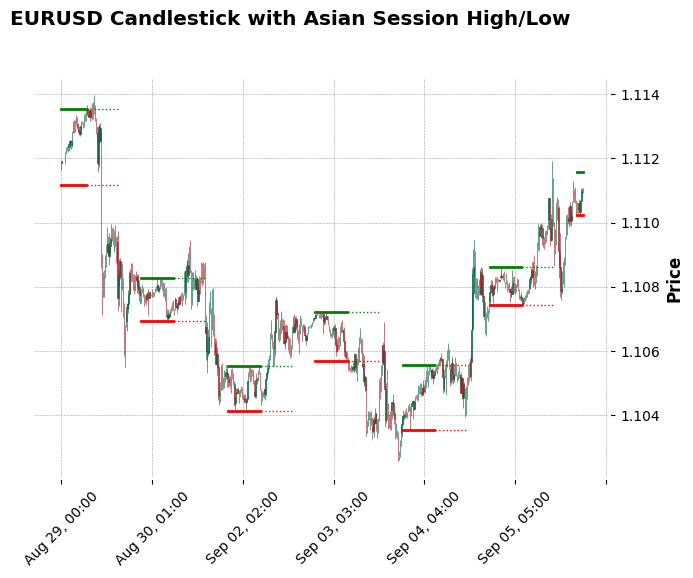

In [24]:
# CHANGE THESE DATES TO CONTROL THE PLOTTED RANGE ---
start_datetime = pd.to_datetime('2024-08-29 00:00:00').tz_localize('GMT')
end_datetime = pd.to_datetime('2024-09-05 23:59:59').tz_localize('GMT')

data = new_df.loc[start_datetime:end_datetime].copy()
# Prepare the data for mplfinance (if not already prepared)
mpf_data = data[['Open', 'High', 'Low', 'Close']]

high_asian = data.loc[data['AsiaOpen'], 'HighAsianSession'].astype(float)
low_asian = data[data['AsiaOpen']]['LowAsianSession'].dropna().astype(float)
high_asian_during_London = data[data['LondonOpen']]['HighAsianSession'].dropna().astype(float)
low_asian_during_London = data[data['LondonOpen']]['LowAsianSession'].dropna().astype(float)

# Ensure indices match between additional plots and candlestick data, leaving unmatched as null
high_asian = high_asian.reindex(mpf_data.index)
low_asian = low_asian.reindex(mpf_data.index)
high_asian_during_London = high_asian_during_London.reindex(mpf_data.index)
low_asian_during_London = low_asian_during_London.reindex(mpf_data.index)

# # Create additional lines for HighAsianSession and LowAsianSession
add_plots = [
    mpf.make_addplot(high_asian, color='green', linestyle='-', width=2),
    mpf.make_addplot(low_asian, color='red', linestyle='-', width=2),
    mpf.make_addplot(high_asian_during_London, color='green', linestyle=':', width=1),
    mpf.make_addplot(low_asian_during_London, color='red', linestyle=':', width=1)
]

# Plot the candlestick chart with additional lines
mpf.plot(mpf_data, type='candle', style='charles', addplot=add_plots,
         title='EURUSD Candlestick with Asian Session High/Low',
         ylabel='Price', volume=False)

plt.show()

## Strategy Definition

`LondonBreakOutStrategy` create strategy class based on the London breakout pattern
Identifies trading opportunities at the opening of the London session by looking for price breakouts from the previous Asian session's high or low

In [25]:
# Calculates the difference between two rates in pips
def calculate_pip_difference(from_rate, to_rate, pip_point=4):

    # Calculate the pip size based on the pip point (e.g., 0.0001 for 4 decimal places)
    pip_size = 10 ** -pip_point
    # Calculate the difference in pips
    pip_difference = (to_rate - from_rate) / pip_size
    return pip_difference

# Calculates a new rate by adding/subtracting a specified number of pips
def calculate_new_rate(rate, pips, pip_point=4):

    # Calculate the pip size
    pip_size = 10 ** -pip_point
    # Calculate the new rate
    new_rate = rate + (pips * pip_size)
    return new_rate

class LondonBreakOutStrategy(Strategy):

    # Strategy Parameters 
    pivot_high_low_bars = 60  # Number of bars to look back for stop-loss pivot (e.g., 60 minutes)
    ratio_profit_loss = 1.4   # Risk-reward ratio for Take Profit (TP) vs Stop Loss (SL)
    
    # Stop Loss (SL) adjustment parameters
    min_SL_pips_trade = 25   # Minimum desired SL in pips. If calculated SL is smaller, it's adjusted
    set_sl_to_min = True     # If True, SL is set to min_SL_pips_trade

    # Take Profit (TP) adjustment parameters
    max_TP_pips_trade = 75   # Maximum desired TP in pips. If calculated TP is larger, it's adjusted
    set_tp_to_max = True     # If True, TP is capped at max_TP_pips_trade

    # Asian Session Range filtering parameters
    trade_in_range_of_asian_session = True # If True, only trades if Asian session range is within limits
    min_asian_session_size = 5     # Minimum Asian session range in pips for a trade
    max_asian_session_size = 80    # Maximum Asian session range in pips for a trade

    # Other general parameters
    pair_pip_point = 4       # Pip decimal place for the currency pair (e.g., 4 for EUR/USD, 2 for USD/JPY)
    
    # Internal variables, typically initialized in __init__ or init()
    total_candles = 0        # Total number of data points in the backtest data.

    # Checks if the strategy has already opened a position or closed a trade on the current trading day-this prevents multiple trades per day
    def did_not_do_a_trade_today(self):
        # If there's an open position, a trade was done today (or before)
        if self.position.size != 0:
            return False
        # Check if any closed trade occurred on the current day
        for trade in self.closed_trades:
            if trade.entry_time.date() == self.data.index[-1].date():
                return False
        return True # No trade has been executed on the current day

    # Initializes strategy-specific variables before the backtest begins
    def init(self):
        # Store the total number of candles in the entire dataset for later use (e.g., closing open positions at end)
        self.total_candles = len(self.data)

    # This method is called for each new bar (candle) of the price data-logic for filtering, trade entry, and exit
    def next(self):
    
        # Initialize filter status to OK. Will be set to False if any filter criteria are not met
        filter_ok = True  

        # Check Asian Session Size filter:
        asian_session_size = (self.data.HighAsianSession[-1] - self.data.LowAsianSession[-1]) * (10**self.pair_pip_point)
        # If the strategy parameter allows filtering by Asian session range
        if self.trade_in_range_of_asian_session:
            # If the Asian session size is too small or too large, set filter_ok to False
            if (asian_session_size < self.min_asian_session_size) or (asian_session_size > self.max_asian_session_size):
                filter_ok = False

        #  TRADE LOGIC 
        # Proceed with trade logic only if all filters are OK and there is no open position
        if filter_ok and self.position.size == 0:

            # -- LONG TRADE (BUY) Condition --
            # Condition: London session is open AND current Close price is above the Asian session High
            # AND no position is currently open AND no trade has been done today yet.
            if self.data.LondonSession[-1] and self.data.Close[-1] > self.data.HighAsianSession[-1] and self.position.size == 0 and self.did_not_do_a_trade_today():
                
                # Determine Stop Loss (SL) rate:
                # The SL is set at the minimum 'Low' price within the last 'pivot_high_low_bars' candles
                SL_rate = min(self.data.Low[-self.pivot_high_low_bars:])
                # Determine Take Profit (TP) rate:
                # TP is calculated based on the current Close, SL, and the defined risk-reward ratio
                TP_rate = self.data.Close[-1] + self.ratio_profit_loss * (self.data.Close[-1] - SL_rate)

                # Calculate SL and TP in pips from the current Close price
                SL_pips = calculate_pip_difference(self.data.Close[-1], SL_rate, self.pair_pip_point)
                TP_pips = calculate_pip_difference(self.data.Close[-1], TP_rate, self.pair_pip_point)

                # -- SL Adjustment -- if the calculated SL is tighter than 'min_SL_pips_trade'
                if abs(SL_pips) < self.min_SL_pips_trade:
                    if self.set_sl_to_min: 
                        # Adjust SL to 'min_SL_pips_trade' below entry
                        SL_rate = calculate_new_rate(self.data.Close[-1], -self.min_SL_pips_trade, self.pair_pip_point)
                        # Recalculate TP based on the new adjusted SL
                        TP_rate = self.data.Close[-1] + self.ratio_profit_loss * (self.data.Close[-1] - SL_rate)
                        SL_pips = calculate_pip_difference(self.data.Close[-1], SL_rate, self.pair_pip_point)
                        TP_pips = calculate_pip_difference(self.data.Close[-1], TP_rate, self.pair_pip_point)
                    # Else (if not set_sl_to_min), the original tighter SL is used

                # -- TP Adjustment -- if the calculated TP is wider than 'max_TP_pips_trade'
                if abs(TP_pips) > self.max_TP_pips_trade:
                    if self.set_tp_to_max: # If adjustment is enabled
                        # Adjust TP to 'max_TP_pips_trade' above entry
                        TP_rate = calculate_new_rate(self.data.Close[-1], self.max_TP_pips_trade, self.pair_pip_point)
                        TP_pips = calculate_pip_difference(self.data.Close[-1], TP_rate, self.pair_pip_point)

                # Execute the BUY order
                try:
                    self.buy(sl=SL_rate, tp=TP_rate)
                except Exception as e:
                    # Print any error during trade execution (e.g., insufficient funds)
                    print(f"Error buying: {e}")
                    pass # Continue to next bar even if trade failed

            # -- SHORT TRADE (SELL) Condition --
            # Condition: London session is open AND current Close price is below the Asian session Low
            # AND no position is currently open AND no trade has been done today yet
            elif self.data.LondonSession[-1] and self.data.Close[-1] < self.data.LowAsianSession[-1] and self.position.size == 0 and self.did_not_do_a_trade_today():
                
                # Determine Stop Loss (SL) rate:
                # The SL is set at the maximum 'High' price within the last 'pivot_high_low_bars' candles
                SL_rate = max(self.data.High[-self.pivot_high_low_bars:])
                # Determine Take Profit (TP) rate:
                # TP is calculated based on the current Close, SL, and risk-reward ratio
                TP_rate = self.data.Close[-1] - self.ratio_profit_loss * (SL_rate - self.data.Close[-1])

                # Calculate SL and TP in pips from the current Close price
                SL_pips = calculate_pip_difference(self.data.Close[-1], SL_rate, self.pair_pip_point)
                TP_pips = calculate_pip_difference(self.data.Close[-1], TP_rate, self.pair_pip_point)

                # -- SL Adjustment --
                # If the calculated SL is tighter than 'min_SL_pips_trade'
                if abs(SL_pips) < self.min_SL_pips_trade:
                    if self.set_sl_to_min: # If adjustment is enabled
                        # Adjust SL to 'min_SL_pips_trade' above entry
                        SL_rate = calculate_new_rate(self.data.Close[-1], self.min_SL_pips_trade, self.pair_pip_point)
                        # Recalculate TP based on the new adjusted SL
                        TP_rate = self.data.Close[-1] - self.ratio_profit_loss * (SL_rate - self.data.Close[-1])
                        SL_pips = calculate_pip_difference(self.data.Close[-1], SL_rate, self.pair_pip_point)
                        TP_pips = calculate_pip_difference(self.data.Close[-1], TP_rate, self.pair_pip_point)
                    # Else (if not set_sl_to_min), the original tighter SL is used

                # -- TP Adjustment --
                # If the calculated TP is wider than 'max_TP_pips_trade'
                if abs(TP_pips) > self.max_TP_pips_trade:
                    if self.set_tp_to_max: # If adjustment is enabled
                        # Adjust TP to 'max_TP_pips_trade' below entry
                        TP_rate = calculate_new_rate(self.data.Close[-1], -self.max_TP_pips_trade, self.pair_pip_point)
                        TP_pips = calculate_pip_difference(self.data.Close[-1], TP_rate, self.pair_pip_point)

                # Execute the SELL order
                try:
                    self.sell(sl=SL_rate, tp=TP_rate)
                except Exception as e:
                    # Print any error during trade execution
                    print(f"Error selling: {e}")
                    pass # Continue to next bar even if trade failed

        # -- End of Backtest Position Closure --
        # Check if the current bar is the last one in the entire dataset.
        if len(self.data) == self.total_candles:
            # If there's an open position at the very end of the backtest, close it.
            if self.position.size > 0:
                self.position.close()

Function next() executes for every candle in the dataframe.

It first computes the pip range between the Asian session’s low and high, and only considers ranges between 10 and 50 pips—since the strategy assumes a “quiet” Asian session and avoids trading if Asian price action was large. It also ensures no position is currently open to avoid re-entering. A long is placed if the previous candle’s close is above the Asian high, and a short if it is below the Asian low.

For the stop loss, I use the highest/lowest point in the last hour rather than a pivot. Take profit uses a 1.4 reward ratio, capped at 75 pips. Very flat Asian sessions with very small stops (e.g., 25 pips) are skipped. The code also prevents more than one trade per day to avoid immediately reopening a closed position. Finally, any open position is closed on the last processed candle if applicable.

### Backtest results

<div class="alert alert-block alert-danger">
<b>‼️</b> 
For this strategy backtest we will consider **NO fees or commissions** which would in real life hinder the performance of the strategy to better assess and build on the trading system
</div>

In [26]:
# Run the backtest
bt = Backtest(new_df, LondonBreakOutStrategy, cash=10000)
stats = bt.run()

# Display the statistics
stats

Backtest.run:   0%|          | 0/24751 [00:00<?, ?bar/s]

C:\Users\user\AppData\Local\Temp\ipykernel_28872\2016869313.py:3: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  stats = bt.run()


Start                     2024-07-22 00:00...
End                       2025-07-18 23:45...
Duration                    361 days 23:45:00
Exposure Time [%]                    67.17033
Equity Final [$]                  10210.79851
Equity Peak [$]                   10256.47101
Return [%]                            2.10799
Buy & Hold Return [%]                 6.80724
Return (Ann.) [%]                     2.11427
Volatility (Ann.) [%]                 6.33586
CAGR [%]                              1.46282
Sharpe Ratio                           0.3337
Sortino Ratio                         0.49381
Calmar Ratio                          0.34541
Alpha [%]                             1.49135
Beta                                  0.09059
Max. Drawdown [%]                    -6.12104
Avg. Drawdown [%]                    -0.38963
Max. Drawdown Duration      287 days 16:45:00
Avg. Drawdown Duration        8 days 23:40:00
# Trades                                  125
Win Rate [%]                      

#### **Plot equity curve and open diagram in browser**

In [27]:
bt.plot(plot_equity=True, plot_return=False)

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\backtesting\_plotting.py:141: UserWarning: Data contains too many candlesticks to plot; downsampling to '1h'. See `Backtest.plot(resample=...)`
  warnings.warn(f"Data contains too many candlesticks to plot; downsampling to {freq!r}. "
c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\bokeh\util\serialization.py:242: UserWarning: no explicit representation of timezones available for np.datetime64
  return convert(array.astype("datetime64[us]"))


GridPlot(id='p2243', ...)


Despite its simplicity the London Breakout strategy returned 2.1% and averaged a 45.6% win rate for 1.4 reward risk ratio and has a sharp ratio of 0.33. Furthermore max drawdown is 3x the overall return before accounting for any fees and commissions

<div class="alert alert-block alert-info">
<b>♾️</b> 
Despite seeminlgy profitable, the backtest suggests that the strategy may require additional parameters or risk management techniques to capture any overall trend of the market and filter for a max trade duration
</div>


***
## ***1.2 - Strategy Improvements (Time & Trend Filters)***
***

The London Breakout Strategy alone has not achieved notable results but can be improved by the use of trend and time filters

### EMA Trend Filter

EMA is a simple but effective indicator of the overall market direction and trend. Filtering for uptrends and downtrands should increase the winning trades by entering positions only in favorable direction
Low timeframe EMA are effective but for this instance we will apply a **600 period EMA** to the 5M price data

### Max Days Filter

Strategy tended to stagnate when price was not breaking high/lows and old positions were open for longer periods of time which introduced randomness and a bottleneck for the next available trade
Max duration of a trade before automatically exited is **4 days**

In [28]:
# A trading strategy based on the London breakout pattern
class LondonBreakOutStrategy(Strategy):

    # -- Strategy Parameters --
    pivot_high_low_bars = 60
    ratio_profit_loss = 1.4
    
    # Stop Loss (SL) adjustment parameters
    min_SL_pips_trade = 25   
    set_sl_to_min = True     

    # Take Profit (TP) adjustment parameters
    max_TP_pips_trade = 75   
    set_tp_to_max = True     

    # Asian Session Range filtering parameters
    trade_in_range_of_asian_session = True 
    min_asian_session_size = 5    
    max_asian_session_size = 80    

    # Other general parameters
    pair_pip_point = 4       
    
    # -- NEW FILTERS PARAMETERS ---
    ema_period = 600  
    exit_days = 4

    # Internal variables
    total_candles = 0   
    trade_entry_time = None # <--- NEW: Variable to manually track entry time     

    # --- Helper Method: Check if a trade was made today ---
    def did_not_do_a_trade_today(self):
        if self.position.size != 0:
            return False
        for trade in self.closed_trades:
            if trade.entry_time.date() == self.data.index[-1].date():
                return False
        return True 

    # --- Initialization Method ---
    def init(self):
        self.total_candles = len(self.data)
        
        # Calculate EMA using Pandas
        self.ema = self.I(lambda x: pd.Series(x).ewm(span=self.ema_period).mean(), self.data.Close)

    # --- Next Bar Method ---
    def next(self):
        
        if self.position.size != 0:
            if self.trade_entry_time is not None:
                current_time = self.data.index[-1]
                time_in_trade = current_time - self.trade_entry_time
                
                # If time in trade exceeds our limit
                if time_in_trade > pd.Timedelta(days=self.exit_days):
                    self.position.close()
                    self.trade_entry_time = None # Reset after closing
                    return 
        else:
            # If no position, ensure entry time is None
            self.trade_entry_time = None

        # --- FILTERS ---
        filter_ok = True 

        asian_session_size = (self.data.HighAsianSession[-1] - self.data.LowAsianSession[-1]) * (10**self.pair_pip_point)
        
        if self.trade_in_range_of_asian_session:
            if (asian_session_size < self.min_asian_session_size) or (asian_session_size > self.max_asian_session_size):
                filter_ok = False

        # --- TRADE LOGIC ---
        if filter_ok and self.position.size == 0:

            # --- LONG TRADE (BUY) Condition ---
            if (self.data.LondonSession[-1] and 
                self.data.Close[-1] > self.data.HighAsianSession[-1] and 
                self.data.Close[-1] > self.ema[-1] and # EMA Filter
                self.position.size == 0 and 
                self.did_not_do_a_trade_today()):
                
                SL_rate = min(self.data.Low[-self.pivot_high_low_bars:])
                TP_rate = self.data.Close[-1] + self.ratio_profit_loss * (self.data.Close[-1] - SL_rate)

                SL_pips = calculate_pip_difference(self.data.Close[-1], SL_rate, self.pair_pip_point)
                TP_pips = calculate_pip_difference(self.data.Close[-1], TP_rate, self.pair_pip_point)

                if abs(SL_pips) < self.min_SL_pips_trade:
                    if self.set_sl_to_min: 
                        SL_rate = calculate_new_rate(self.data.Close[-1], -self.min_SL_pips_trade, self.pair_pip_point)
                        TP_rate = self.data.Close[-1] + self.ratio_profit_loss * (self.data.Close[-1] - SL_rate)
                        SL_pips = calculate_pip_difference(self.data.Close[-1], SL_rate, self.pair_pip_point)
                        TP_pips = calculate_pip_difference(self.data.Close[-1], TP_rate, self.pair_pip_point)

                if abs(TP_pips) > self.max_TP_pips_trade:
                    if self.set_tp_to_max: 
                        TP_rate = calculate_new_rate(self.data.Close[-1], self.max_TP_pips_trade, self.pair_pip_point)
                        TP_pips = calculate_pip_difference(self.data.Close[-1], TP_rate, self.pair_pip_point)

                try:
                    self.buy(sl=SL_rate, tp=TP_rate)
                    # <--- RECORD ENTRY TIME MANUALLY
                    self.trade_entry_time = self.data.index[-1] 
                except Exception as e:
                    print(f"Error buying: {e}")
                    pass 

            # --- SHORT TRADE (SELL) Condition ---
            elif (self.data.LondonSession[-1] and 
                  self.data.Close[-1] < self.data.LowAsianSession[-1] and 
                  self.data.Close[-1] < self.ema[-1] and # EMA Filter
                  self.position.size == 0 and 
                  self.did_not_do_a_trade_today()):
                
                SL_rate = max(self.data.High[-self.pivot_high_low_bars:])
                TP_rate = self.data.Close[-1] - self.ratio_profit_loss * (SL_rate - self.data.Close[-1])

                SL_pips = calculate_pip_difference(self.data.Close[-1], SL_rate, self.pair_pip_point)
                TP_pips = calculate_pip_difference(self.data.Close[-1], TP_rate, self.pair_pip_point)

                if abs(SL_pips) < self.min_SL_pips_trade:
                    if self.set_sl_to_min: 
                        SL_rate = calculate_new_rate(self.data.Close[-1], self.min_SL_pips_trade, self.pair_pip_point)
                        TP_rate = self.data.Close[-1] - self.ratio_profit_loss * (SL_rate - self.data.Close[-1])
                        SL_pips = calculate_pip_difference(self.data.Close[-1], SL_rate, self.pair_pip_point)
                        TP_pips = calculate_pip_difference(self.data.Close[-1], TP_rate, self.pair_pip_point)

                if abs(TP_pips) > self.max_TP_pips_trade:
                    if self.set_tp_to_max: 
                        TP_rate = calculate_new_rate(self.data.Close[-1], -self.max_TP_pips_trade, self.pair_pip_point)
                        TP_pips = calculate_pip_difference(self.data.Close[-1], TP_rate, self.pair_pip_point)

                try:
                    self.sell(sl=SL_rate, tp=TP_rate)
                    # <--- RECORD ENTRY TIME MANUALLY
                    self.trade_entry_time = self.data.index[-1]
                except Exception as e:
                    print(f"Error selling: {e}")
                    pass 

        # --- End of Backtest Position Closure ---
        if len(self.data) == self.total_candles:
            if self.position.size > 0:
                self.position.close()

In [29]:
bt = Backtest(new_df, LondonBreakOutStrategy, cash=10_000)
stats = bt.run()
stats

Backtest.run:   0%|          | 0/24751 [00:00<?, ?bar/s]

C:\Users\user\AppData\Local\Temp\ipykernel_28872\727844919.py:2: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  stats = bt.run()


Start                     2024-07-22 00:00...
End                       2025-07-18 23:45...
Duration                    361 days 23:45:00
Exposure Time [%]                    51.62007
Equity Final [$]                  11078.11498
Equity Peak [$]                   11126.76011
Return [%]                           10.78115
Buy & Hold Return [%]                 6.80724
Return (Ann.) [%]                    10.44377
Volatility (Ann.) [%]                 5.96135
CAGR [%]                              7.38782
Sharpe Ratio                          1.75191
Sortino Ratio                         3.06517
Calmar Ratio                          3.02265
Alpha [%]                            10.83743
Beta                                 -0.00827
Max. Drawdown [%]                    -3.45517
Avg. Drawdown [%]                     -0.2762
Max. Drawdown Duration       81 days 09:30:00
Avg. Drawdown Duration        2 days 21:51:00
# Trades                                  132
Win Rate [%]                      

In [30]:
bt.plot(plot_equity=True, plot_return=False) # Plot in a browser window  

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\backtesting\_plotting.py:141: UserWarning: Data contains too many candlesticks to plot; downsampling to '1h'. See `Backtest.plot(resample=...)`
  warnings.warn(f"Data contains too many candlesticks to plot; downsampling to {freq!r}. "
c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\bokeh\util\serialization.py:242: UserWarning: no explicit representation of timezones available for np.datetime64
  return convert(array.astype("datetime64[us]"))


GridPlot(id='p2564', ...)


This time the strategy returned 10.8% compared to a 6.8% return on buy&hold. Considering the strategy's max drawdown was only 3.5% this makes it a very safe and robust trading system on paper.

Notebly, the number of trades increased despite setting a filter for 'false' signals from 125 to 132. This could be due to the max duration filter which allows for a quick exit and new breakout to be found if price didnt reach the treshold yet

***
## ***1.3 - Out of Sample Backtest***
***



To help confirm the strenght & robustness of the improved London Breakout strategy we must test the system on a new set of unseen data. We will use the 7 months of price data beginning with the end of previous dataset (July 2025)

`003/EUR-USD_Minute_2026-01-06_Pacific_Norfolk.csv` has been compiled from 5M EURUSD price datasets from *dukascopy*
Price is recorded in a Pacific (Norfolk) timezone +13 of UTC 
`source_fixed_offset_tz` localize to original timezone datetime object

In [31]:
new_df = pd.read_csv('003/EUR-USD_Minute_2026-01-06_Pacific_Norfolk.csv', delimiter=',')
new_df.rename(columns={'Pacific/Norfolk': 'time'}, inplace=True)
new_df.rename(columns={'Pacific/Fakaofo': 'time'}, inplace=True) # check for download errors

# 3. Create a timezone-NAIVE datetime object first.
# We'll explicitly remove the " UTC+13:00" part for robust parsing of date and time.
new_df['time'] = pd.to_datetime(new_df['time'].str.replace(' UTC+13:00', ''), format='%d.%m.%Y %H:%M:%S.%f')

# 4. NOW, localize this timezone-naive datetime object to its *original* timezone (UTC+13:00).
# We use pytz.FixedOffset for this, as it's a fixed offset rather than a named timezone with DST rules.
# 13 hours * 60 minutes/hour = 780 minutes
source_fixed_offset_tz = pytz.FixedOffset(13 * 60)
new_df['time'] = new_df['time'].dt.tz_localize(source_fixed_offset_tz)

new_df['time'] = new_df['time'].dt.tz_convert('UTC')
new_df.set_index('time', inplace=True)
new_df.drop(columns=['Volume'], inplace=True)

print(new_df.head())
print(new_df.tail())
new_df.info()

                              Open     High      Low    Close
time                                                         
2025-07-21 00:00:00+00:00  1.16296  1.16330  1.16272  1.16321
2025-07-21 00:05:00+00:00  1.16322  1.16322  1.16308  1.16315
2025-07-21 00:10:00+00:00  1.16314  1.16359  1.16314  1.16359
2025-07-21 00:15:00+00:00  1.16359  1.16362  1.16315  1.16320
2025-07-21 00:20:00+00:00  1.16320  1.16324  1.16303  1.16303
                              Open     High      Low    Close
time                                                         
2026-02-13 20:35:00+00:00  1.18669  1.18675  1.18656  1.18669
2026-02-13 20:40:00+00:00  1.18669  1.18694  1.18666  1.18689
2026-02-13 20:45:00+00:00  1.18688  1.18699  1.18665  1.18691
2026-02-13 20:50:00+00:00  1.18692  1.18708  1.18679  1.18705
2026-02-13 20:55:00+00:00  1.18704  1.18745  1.18704  1.18741
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 37559 entries, 2025-07-21 00:00:00+00:00 to 2026-02-13 20:55:00+00:00
Data colu

### Update dataset

C:\Users\user\AppData\Local\Temp\ipykernel_28872\1932855251.py:91: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  new_df["HighAsianSession"] = new_df["HighAsianSession"].fillna(method='ffill')
C:\Users\user\AppData\Local\Temp\ipykernel_28872\1932855251.py:97: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  new_df['LowAsianSession'] = new_df["LowAsianSession"].fillna(method='ffill')
c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the numbe

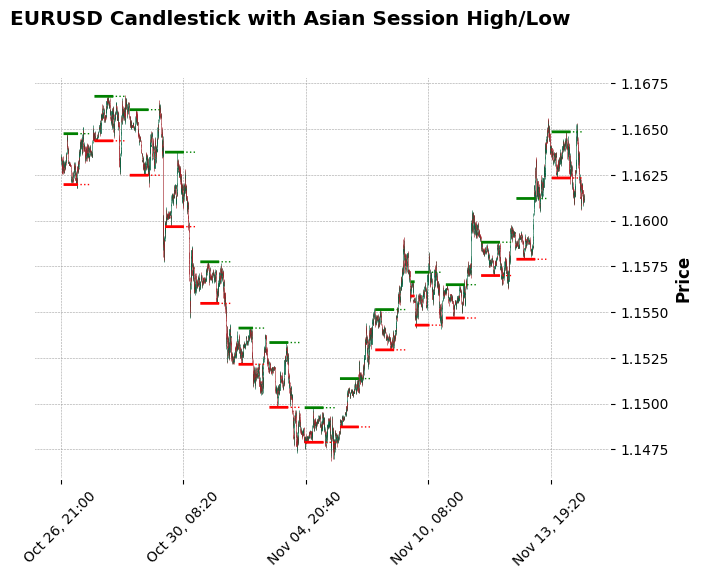

In [32]:
class ForexMarket(Enum):
    LONDON = "London"
    TOKYO = "Tokyo"
    SYDNEY = "Sydney"
    NEW_YORK = "New York"

# Function takes a ForexMarket enum member and a timezone-aware datetime object (gmt_time) as input.
def is_market_open(market: ForexMarket, gmt_time: datetime) -> bool:
    # The new_df index should already be UTC-aware, but this check adds robustness.
    if gmt_time.tzinfo is None:  # If it's a naive datetime (without timezone info)
        gmt_time = pytz.UTC.localize(gmt_time)
    elif gmt_time.tzinfo != pytz.UTC:
        gmt_time = gmt_time.astimezone(pytz.UTC)

# DST Calculation for Northern Hemisphere
    dst_start = datetime(gmt_time.year, 3, 31, 1, tzinfo=pytz.UTC) # Start of Mar 31
    while dst_start.weekday() != 6: # Go back until Sunday (weekday() for Sunday is 6)
        dst_start -= pd.Timedelta(days=1)
    dst_start = dst_start.replace(hour=1) # Market typically opens at 1am UTC for DST change

    dst_end = datetime(gmt_time.year, 10, 31, 1, tzinfo=pytz.UTC) # Start of Oct 31
    while dst_end.weekday() != 6: # Go back until Sunday
        dst_end -= pd.Timedelta(days=1)
    dst_end = dst_end.replace(hour=1) # Market typically opens at 1am UTC for DST change


    # Define market open and close times in GMT/UTC - adjusted based on whether the current gmt_time falls within the DST period
    if dst_start <= gmt_time < dst_end:
        # SUMMER TIME (when countries like UK are in BST, which is UTC+1; or New York is EDT, UTC-4)
        market_hours = {
            ForexMarket.LONDON: (time(7, 0), time(16, 0)),  # 8am-5pm BST (UTC+1), so 7am-4pm UTC
            ForexMarket.TOKYO: (time(23, 0), time(8, 0)),   # 8am-5pm JST (UTC+9), so 23pm-8am UTC (overnight)
            ForexMarket.SYDNEY: (time(22, 0), time(7, 0)),  # 7am-4pm AEST (UTC+10), so 22pm-7am UTC (overnight)
            ForexMarket.NEW_YORK: (time(12, 0), time(21, 0)) # 8am-5pm EDT (UTC-4), so 12pm-9pm UTC
        }
    else:
        # WINTER TIME (when countries like UK are in GMT, UTC+0; or New York is EST, UTC-5)
        market_hours = {
            ForexMarket.LONDON: (time(8, 0), time(17, 0)),  # 8am-5pm GMT, so 8am-5pm UTC
            ForexMarket.TOKYO: (time(0, 0), time(9, 0)),    # 8am-5pm JST (UTC+9), so 0am-9am UTC (overnight)
            ForexMarket.SYDNEY: (time(21, 0), time(6, 0)),  # 7am-4pm AEDT (UTC+11), so 21pm-6am UTC (overnight, due to Southern Hemi DST)
            ForexMarket.NEW_YORK: (time(13, 0), time(22, 0)) # 8am-5pm EST (UTC-5), so 1pm-10pm UTC
        }

    # Check if it's a weekend (Saturday or Sunday)
    if gmt_time.weekday() >= 5:  # Saturday (5) or Sunday (6)
        return False
    open_time, close_time = market_hours[market]
    if open_time < close_time:
        return open_time <= gmt_time.time() < close_time
    else:
        return gmt_time.time() >= open_time or gmt_time.time() < close_time

# Create boolean columns indicating if each major Forex market is open
new_df['LondonOpen'] = new_df.index.map(lambda x: is_market_open(ForexMarket.LONDON, x))
new_df['TokyoOpen'] = new_df.index.map(lambda x: is_market_open(ForexMarket.TOKYO, x))
new_df['SydneyOpen'] = new_df.index.map(lambda x: is_market_open(ForexMarket.SYDNEY, x))
new_df['NewYorkOpen'] = new_df.index.map(lambda x: is_market_open(ForexMarket.NEW_YORK, x))

# Define 'AsiaOpen' as when either Tokyo or "|" Sydney markets are open
new_df['AsiaOpen'] = new_df['TokyoOpen'] | new_df['SydneyOpen']
# Set 'AsiaOpen' to specifically mean the Asian session *excluding* the London session overlap
new_df['AsiaOpen'] = new_df['AsiaOpen'] & ~new_df['LondonOpen']

# Function to compute continuous True indices
def identity_market_sessions(df_data: pd.DataFrame, boolean_column: str) -> list:

    continuous_true = []
    current_block_start_index = None # Keeps track of the start time of a continuous 'True' block

    # Iterate through the DataFrame's boolean column and its index
    for index, value in df_data[boolean_column].items():
        if value:  # If the current minute is marked as 'True' (market is open)
            if current_block_start_index is None: # If this is the FIRST 'True' in a new continuous block
                current_block_start_index = index # Mark the current index as the start of this block
            continuous_true.append(current_block_start_index) # Append the block's start index
        else:  # If the current minute is marked as 'False' (market is closed)
            current_block_start_index = None # Reset the block start tracker
            continuous_true.append(None) # Append None, as the market is not open
    return continuous_true

new_df['TokyoSession'] = identity_market_sessions(new_df, 'TokyoOpen')
new_df['SydneySession'] = identity_market_sessions(new_df, 'SydneyOpen')
new_df['NewYorkSession'] = identity_market_sessions(new_df, 'NewYorkOpen')
new_df['AsianSession'] = identity_market_sessions(new_df, 'AsiaOpen') # Based on the refined AsiaOpen flag
new_df['LondonSession'] = identity_market_sessions(new_df, 'LondonOpen')

# Calculate the High of each Asian Session:
new_df['HighAsianSession'] = new_df.groupby('AsianSession')['High'].transform('max').where(new_df['AsiaOpen'])
# Forward-fill - once an Asian session's high is calculated, it is carried forward to subsequent time periods until the next Asian session's high is available
new_df["HighAsianSession"] = new_df["HighAsianSession"].fillna(method='ffill')
# Apply a 'safety' condition: set 'HighAsianSession' to NaN when both London and Asian markets are closed
new_df.loc[(new_df["LondonOpen"] == False) & (new_df["AsiaOpen"] == False), "HighAsianSession"] = np.nan
# Calculate the Low of each Asian Session, following same logic as for HighAsianSession
new_df['LowAsianSession'] = new_df.groupby('AsianSession')['Low'].transform('min').where(new_df['AsiaOpen'])
# Forward-fill the 'LowAsianSession' values to extend the range.
new_df['LowAsianSession'] = new_df["LowAsianSession"].fillna(method='ffill')
# Apply the same 'safety' condition
new_df.loc[(new_df["LondonOpen"] == False) & (new_df["AsiaOpen"] == False), "LowAsianSession"] = np.nan
new_df

start_datetime = pd.to_datetime('2025-10-26 00:00:00').tz_localize('GMT')
end_datetime = pd.to_datetime('2025-11-14 18:00:00').tz_localize('GMT') # Adjusted end_datetime for example data display

# Use new_df for slicing
data = new_df.loc[start_datetime:end_datetime].copy()
# Prepare the data for mplfinance
mpf_data = data[['Open', 'High', 'Low', 'Close']]
high_asian = data.loc[data['AsiaOpen'], 'HighAsianSession'].astype(float)
low_asian = data[data['AsiaOpen']]['LowAsianSession'].dropna().astype(float)
high_asian_during_London = data[data['LondonOpen']]['HighAsianSession'].dropna().astype(float)
low_asian_during_London = data[data['LondonOpen']]['LowAsianSession'].dropna().astype(float)

# Ensure indices match between additional plots and candlestick data, leaving unmatched as null
high_asian = high_asian.reindex(mpf_data.index)
low_asian = low_asian.reindex(mpf_data.index)
high_asian_during_London = high_asian_during_London.reindex(mpf_data.index)
low_asian_during_London = low_asian_during_London.reindex(mpf_data.index)

# # Create additional lines for HighAsianSession and LowAsianSession
add_plots = [
    mpf.make_addplot(high_asian, color='green', linestyle='-', width=2),
    mpf.make_addplot(low_asian, color='red', linestyle='-', width=2),
    mpf.make_addplot(high_asian_during_London, color='green', linestyle=':', width=1),
    mpf.make_addplot(low_asian_during_London, color='red', linestyle=':', width=1)
]
# Plot the candlestick chart with additional lines
mpf.plot(mpf_data, type='candle', style='charles', addplot=add_plots,
         title='EURUSD Candlestick with Asian Session High/Low',
         ylabel='Price', volume=False)

plt.show()

#### Run backtest (strategy class already saved)

In [33]:
bt = Backtest(new_df, LondonBreakOutStrategy, cash=10_000)
stats = bt.run()
stats

Backtest.run:   0%|          | 0/37558 [00:00<?, ?bar/s]

C:\Users\user\AppData\Local\Temp\ipykernel_28872\727844919.py:2: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  stats = bt.run()


Start                     2025-07-21 00:00...
End                       2026-02-13 20:55...
Duration                    207 days 20:55:00
Exposure Time [%]                     58.1991
Equity Final [$]                  10551.42988
Equity Peak [$]                   10599.53882
Return [%]                             5.5143
Buy & Hold Return [%]                 2.08045
Return (Ann.) [%]                     8.18458
Volatility (Ann.) [%]                 4.57178
CAGR [%]                              6.72349
Sharpe Ratio                          1.79024
Sortino Ratio                         3.42016
Calmar Ratio                          3.81165
Alpha [%]                             5.63662
Beta                                 -0.05879
Max. Drawdown [%]                    -2.14725
Avg. Drawdown [%]                    -0.14445
Max. Drawdown Duration       66 days 03:00:00
Avg. Drawdown Duration        1 days 07:57:00
# Trades                                   90
Win Rate [%]                      

In [34]:
bt.plot(plot_equity=True, plot_return=False) # Plot in a browser window

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\backtesting\_plotting.py:141: UserWarning: Data contains too many candlesticks to plot; downsampling to '30min'. See `Backtest.plot(resample=...)`
  warnings.warn(f"Data contains too many candlesticks to plot; downsampling to {freq!r}. "
c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\bokeh\util\serialization.py:242: UserWarning: no explicit representation of timezones available for np.datetime64
  return convert(array.astype("datetime64[us]"))


GridPlot(id='p2886', ...)

#### Annualized Return   8.2%
#### Max Drawdown   -2.1%
#### Sharpe Ratio   1.8

## Is this strategy great? Is it overfitted?

Backtesting on EUR/USD has produced relativey good results and employing leverage can vastly outperform the market at similar levels or risk. Despite a limited data to backtest on and despite not cosidering any trading costs in this notebook this strategy appears to be more robust and more profitable than most buy&hold approaches

Strategy is not clearly overfitted.  Nevertheless, some of the parameters (SLTP, max pip, EMA) have been explored prior (although not optimized) and thus the results in this backtest can fall to overfitting bias to some extend

<div class="alert alert-block alert-warning">
<b>🔆</b> For a deeper exploration of London Breakout try backtesting on other Forex currencies & adjust sessions as necessary, also consider tightening filter parameters and trading more pairs for more signals
</div>

## Strategy Improvements

Applying regime or trend filters might run the risk or overfitting and might make the strategy more random

Time filters - for example going long on a breakout above the Asian high and exiting between 12:00 and 17:00 London time frequently might prove more profitable than different hours

## Performance Charts from Web Browser display

### 1.1 Evaluation
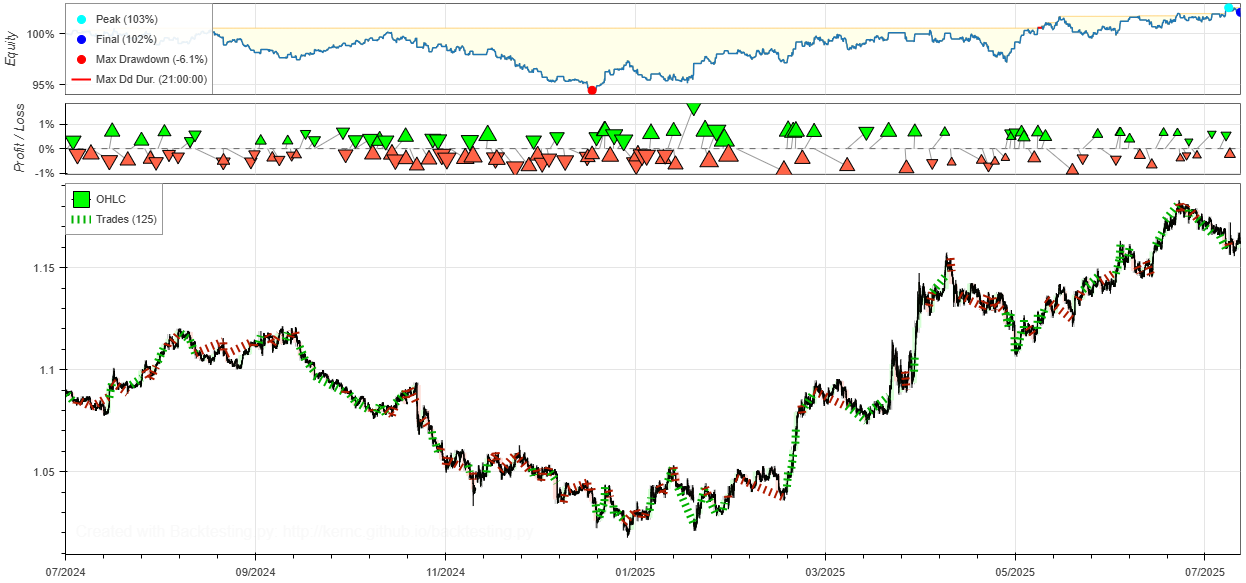
### 1.2 Filter Improvement
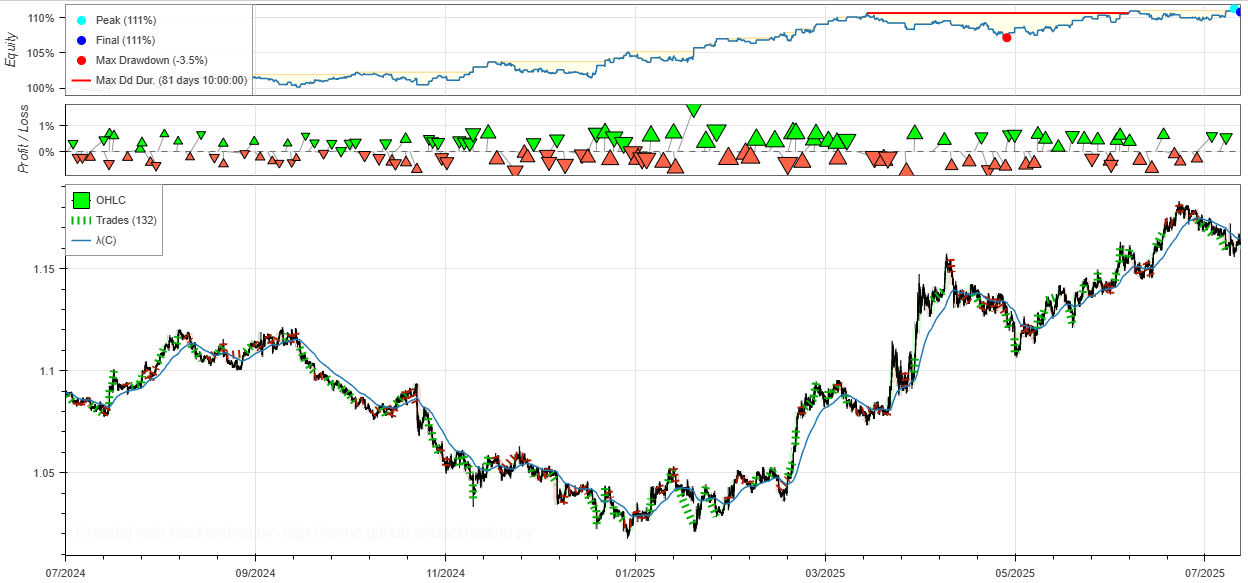
### 1.3 Out-of-Sample
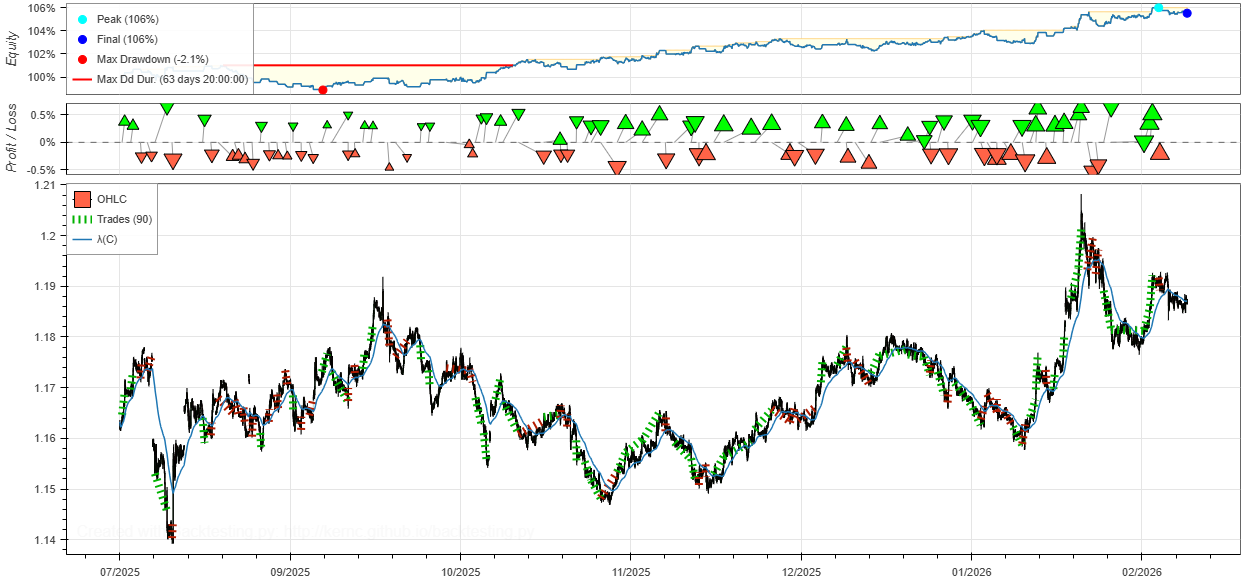

***
### *CREDITS*

Historical price data from [dukascopy.com](https://www.dukascopy.com/swiss/english/marketwatch/historical/)  
**Yves Hilpisch**, *O'REILLY*, 2021, Python for Algorithmic Trading  
[wire.insiderfinance.io](https://wire.insiderfinance.io/backtest-results-revealed-is-the-london-breakout-strategy-worth-it-0e9df65dd63b) Backtest Results Revealed: Is the London Breakout Strategy Worth It?